# Báo cáo bài tập thực hành tuần 7
> Họ và tên: Nguyễn Vạn Phúc Huy <br>
> MSSV: 23110163 <br>
> Lớp: 23TTH (Chiều thứ 6, ca 1)

### Viết chương trình để thực thi thuật toán hierarchical sử dụng phương pháp hợp nhất Bottom-up với single-linkage, complete-linkage và average-linkage.

```py
class HierarchicalClustering:
    def __init__(self, data, K, linkage='single'):
        self.data = data.values.tolist()
        self.col = data.columns
        self.N = len(data)
        self.K = K
        self.linkage = linkage 
        self.clusters = self.init_clusters()

    def init_clusters(self):
        return {data_id: [data_point] for data_id, data_point in enumerate(self.data)}

    # 1. Single-linkage
    def single_link(self, ci, cj):
        return np.min([np.linalg.norm(np.array(vi)-np.array(vj)) for vi in ci for vj in cj])

    # 2. Complete-linkage
    def complete_link(self, ci, cj):
        return np.max([np.linalg.norm(np.array(vi)-np.array(vj)) for vi in ci for vj in cj])

    # 3. Average-linkage
    def average_link(self, ci, cj):
        return np.mean([np.linalg.norm(np.array(vi)-np.array(vj)) for vi in ci for vj in cj])

    def calculate_distance(self, ci, cj):
        if self.linkage == 'single':
            return self.single_link(ci, cj)
        elif self.linkage == 'complete':
            return self.complete_link(ci, cj)
        elif self.linkage == 'average':
            return self.average_link(ci, cj)
        else:
            raise ValueError("Tham số linkage phải là 'single', 'complete' hoặc 'average'")

    def find_closest_clusters(self):
        clusters_ids = list(self.clusters.keys())

        cluster_combinations = [(clusters_ids[i], clusters_ids[j])
                                for i in range(len(clusters_ids)-1)
                                for j in range(i+1, len(clusters_ids))]

        distances = [self.calculate_distance(self.clusters[ci], self.clusters[cj])
                     for ci, cj in cluster_combinations]

        closest_index = np.argmin(distances)
        closest_clusters = cluster_combinations[closest_index]

        return closest_clusters

    def merge_clusters(self, ci_id, cj_id):
        new_clusters = {0: self.clusters[ci_id] + self.clusters[cj_id]}
        new_cluster_id = 1

        for cluster_id, points in self.clusters.items():
            if cluster_id != ci_id and cluster_id != cj_id:
                new_clusters[new_cluster_id] = points
                new_cluster_id += 1

        return new_clusters

    def run(self):
        while len(self.clusters.keys()) > self.K:
            closest_clusters = self.find_closest_clusters()
            self.clusters = self.merge_clusters(*closest_clusters)

    def plot_clusters(self):
        cluster_ids = list(self.clusters.keys())
        num_clusters = len(cluster_ids)
        colors = sns.color_palette('rainbow', n_colors=num_clusters)
        fig, ax = plt.subplots()
        
        for i, cluster_id in enumerate(cluster_ids):
            points = self.clusters[cluster_id]
            x = [point[0] for point in points]
            y = [point[1] for point in points]
            ax.scatter(x, y, color=colors[i], label=f'Cluster {cluster_id}')
            
        ax.set_xlabel(self.col[0])
        ax.set_ylabel(self.col[1]) 
        ax.set_title(f'Hierarchical Clustering ({self.linkage}-linkage)')

        ax.legend()
        plt.show()
```

Class `HierarchicalClustering` đã được định nghĩa để thực thi thuật toán hierarchical clustering với ba phương pháp hợp nhất: single-linkage, complete-linkage và average-linkage. Hoạt động như sau:
- Hàm `__init__` khởi tạo đối tượng với dữ liệu, số cột, n (số lượng mẫu), số lượng cụm K và phương pháp hợp nhất.
```py 
def __init__(self, data, K, linkage='single'):
    self.data = data.values.tolist()
    self.col = data.columns
    self.N = len(data)
    self.K = K
    self.linkage = linkage 
    self.clusters = self.init_clusters()
```

- Hàm `init_clusters` khởi tạo các cụm ban đầu, mỗi mẫu là một cụm riêng biệt.
```py
def init_clusters(self):
    return {data_id: [data_point] for data_id, data_point in enumerate(self.data)}
```

- Các hàm `single_link`, `complete_link` và `average_link` tính toán khoảng cách giữa hai cụm theo phương pháp tương ứng.
    - `single_link` tính khoảng cách nhỏ nhất giữa các điểm của hai cụm.
    ```py
    def single_link(self, ci, cj):
        return np.min([np.linalg.norm(np.array(vi)-np.array(vj)) for vi in ci for vj in cj])    
    ``` 
    - `complete_link` tính khoảng cách lớn nhất giữa các điểm của hai cụm.
    ```py
    def complete_link(self, ci, cj):
        return np.max([np.linalg.norm(np.array(vi)-np.array(vj)) for vi in ci for vj in cj])
    ```
    - `average_link` tính khoảng cách trung bình giữa các điểm của hai cụm.
    ```py
    def average_link(self, ci, cj):
        return np.mean([np.linalg.norm(np.array(vi)-np.array(vj)) for vi in ci for vj in cj])
    ```
- Hàm `calculate_distance` chọn phương pháp hợp nhất dựa trên tham số `linkage` được cung cấp.
```py
def calculate_distance(self, ci, cj):
    if self.linkage == 'single':
        return self.single_link(ci, cj)
    elif self.linkage == 'complete':
        return self.complete_link(ci, cj)
    elif self.linkage == 'average':
        return self.average_link(ci, cj)
    else:
        raise ValueError("Tham số linkage phải là 'single', 'complete' hoặc 'average'")
```
- Hàm `find_closest_clusters` tìm cặp cụm gần nhất dựa trên khoảng cách được tính toán. Hoạt động bằng cách:
    - Tạo danh sách các cặp cụm có thể.
    - Tính khoảng cách cho mỗi cặp cụm.
    - Xác định cặp cụm có khoảng cách nhỏ nhất và trả về cặp đó.
```py
def find_closest_clusters(self):
    clusters_ids = list(self.clusters.keys())

    cluster_combinations = [(clusters_ids[i], clusters_ids[j])
                            for i in range(len(clusters_ids)-1)
                            for j in range(i+1, len(clusters_ids))]

    distances = [self.calculate_distance(self.clusters[ci], self.clusters[cj])
                 for ci, cj in cluster_combinations]

    closest_index = np.argmin(distances)
    closest_clusters = cluster_combinations[closest_index]

    return closest_clusters
```
- Hàm `merge_clusters` hợp nhất hai cụm được chỉ định thành một cụm mới và cập nhật danh sách các cụm. Hoạt động bằng cách:
    - Tạo một từ điển mới để lưu trữ các cụm sau khi hợp nhất.
    - Hợp nhất hai cụm được chỉ định thành một cụm mới với ID 0.
    - Thêm các cụm còn lại vào từ điển mới với ID mới.
```py
def merge_clusters(self, ci_id, cj_id):
    new_clusters = {0: self.clusters[ci_id] + self.clusters[cj_id]}
    new_cluster_id = 1
    for cluster_id, points in self.clusters.items():
        if cluster_id != ci_id and cluster_id != cj_id:
            new_clusters[new_cluster_id] = points
            new_cluster_id += 1
    return new_clusters
```
- Hàm `run` thực thi thuật toán hierarchical clustering cho đến khi số lượng cụm còn lại bằng K. Hoạt động bằng cách:
    - Trong khi số lượng cụm lớn hơn K, tìm cặp cụm gần nhất và hợp nhất chúng.
```py
def run(self):
    while len(self.clusters.keys()) > self.K:
        closest_clusters = self.find_closest_clusters()
        self.clusters = self.merge_clusters(*closest_clusters)
```
- Hàm `plot_clusters` vẽ biểu đồ phân cụm sau khi thuật toán đã hoàn thành. Hoạt động bằng cách:
    - Lấy danh sách ID của các cụm và số lượng cụm.
    - Tạo một biểu đồ phân tán với màu sắc khác nhau cho mỗi cụm.
    - Đặt nhãn cho trục x, trục y và tiêu đề biểu đồ.
    - Hiển thị biểu đồ.
```py
def plot_clusters(self):
    cluster_ids = list(self.clusters.keys())
    num_clusters = len(cluster_ids)
    colors = sns.color_palette('rainbow', n_colors=num_clusters)
    fig, ax = plt.subplots()
    for i, cluster_id in enumerate(cluster_ids):
        points = self.clusters[cluster_id]
        x = [point[0] for point in points]
        y = [point[1] for point in points]
        ax.scatter(x, y, color=colors[i], label=f'Cluster {cluster_id}')
    ax.set_xlabel(self.col[0])
    ax.set_ylabel(self.col[1])
    ax.set_title(f'Hierarchical Clustering ({self.linkage}-linkage)')
    ax.legend()
    plt.show()
```



#### Single-linkage

Code viết bằng cơm

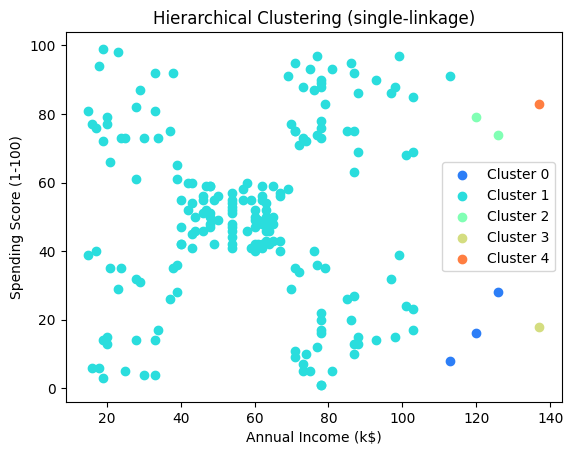

In [31]:
hierarchical_clustering_single = HierarchicalClustering(selected_data, 5, linkage='single')
hierarchical_clustering_single.run()
hierarchical_clustering_single.plot_clusters()

Code hàm có sẵn

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 0 1 0 4 0 4 3 2]


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

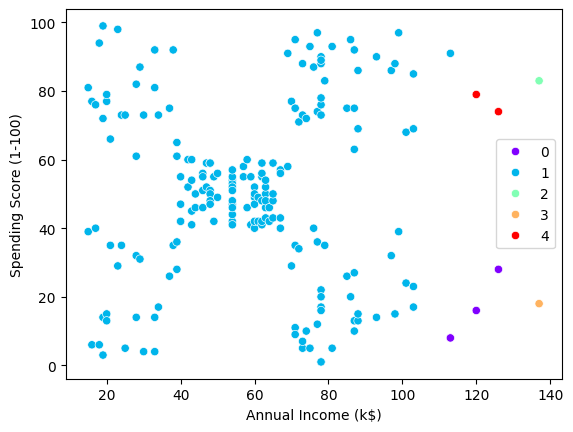

In [32]:
clustering_model_single = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='single')
clustering_model_single.fit(selected_data)

data_labels = clustering_model_single.labels_
print(data_labels)

sns.scatterplot(x = customer_data['Annual Income (k$)'], y = customer_data['Spending Score (1-100)'],data = selected_data, hue=data_labels, palette='rainbow')

#### Complete-linkage

Code viết bằng cơm

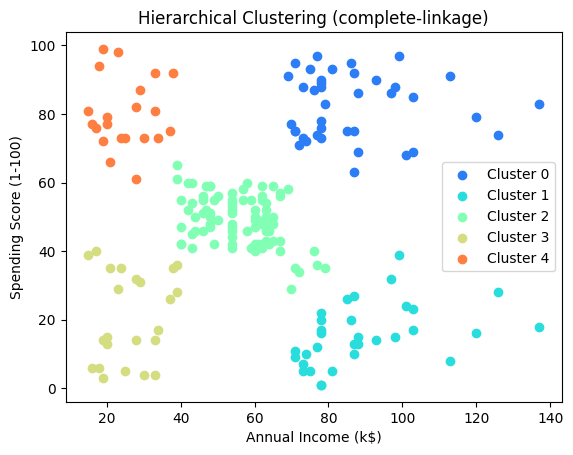

In [33]:
hierarchical_clustering_complete = HierarchicalClustering(selected_data, 5, linkage='complete')
hierarchical_clustering_complete.run()
hierarchical_clustering_complete.plot_clusters()

Code hàm có sẵn

[4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4
 3 4 3 4 3 4 1 4 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 0 2 0 2 0 1 0 2 0 2 0 2 0 2 0 1 0 2 0 1 0
 2 0 2 0 2 0 2 0 2 0 2 0 1 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2
 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0]


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

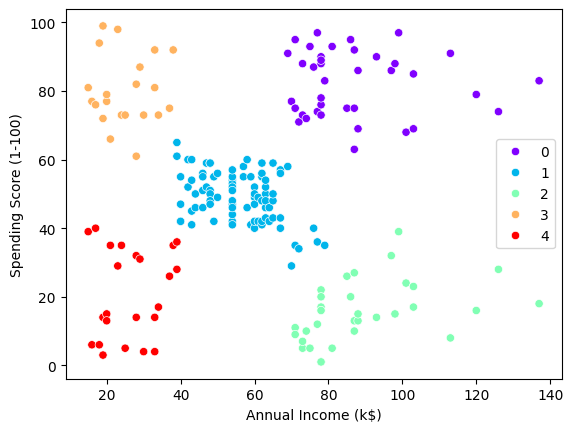

In [34]:
clustering_model_complete = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='complete')
clustering_model_complete.fit(selected_data)

data_labels = clustering_model_complete.labels_
print(data_labels)

sns.scatterplot(x = customer_data['Annual Income (k$)'], y = customer_data['Spending Score (1-100)'],data = selected_data, hue=data_labels, palette='rainbow')

#### Average-linkage

Code viết bằng cơm

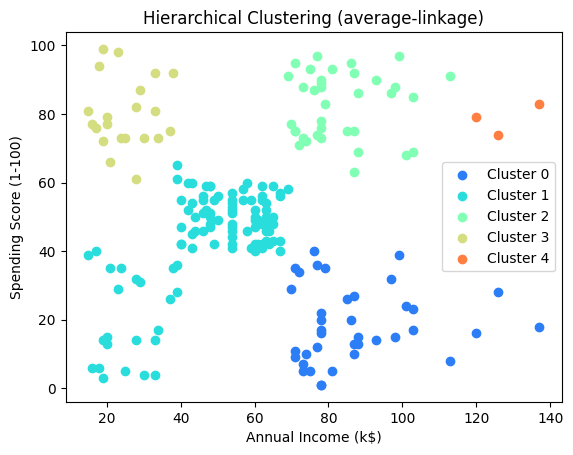

In [36]:
hierarchical_clustering_average = HierarchicalClustering(selected_data, 5, linkage='average')
hierarchical_clustering_average.run()
hierarchical_clustering_average.plot_clusters()

Code hàm có sẵn

[1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1
 3 1 3 1 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2
 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 4 0 4 0 4]


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

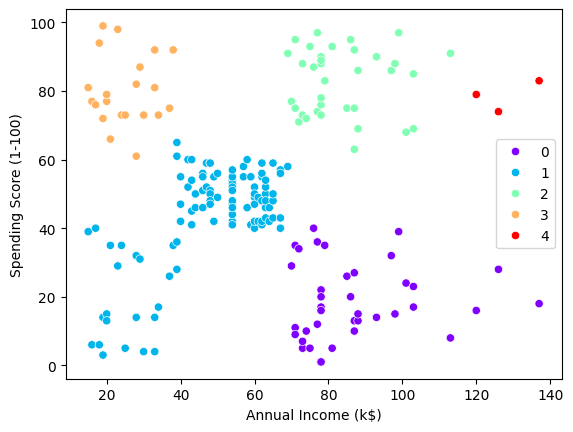

In [35]:
clustering_model_complete = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='average')
clustering_model_complete.fit(selected_data)

data_labels = clustering_model_complete.labels_
print(data_labels)

sns.scatterplot(x = customer_data['Annual Income (k$)'], y = customer_data['Spending Score (1-100)'],data = selected_data, hue=data_labels, palette='rainbow')